In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
import pandas as pd
from ctplanet import pyMoho
from ctplanet import pyMohoRho
import boule as bl
from pathlib import Path

pygmt-session [ERROR]: Cannot find the PSL_UTF-8 encoding
begin [ERROR]: Cannot find the PSL_UTF-8 encoding


In [2]:
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719.sh"
density_output=PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719_DH2.txt"
result_filename=PROJECT_ROOT/"result/frequency_domain_run1.pkl"

读取数据

Wiecorek et al., 2013 的月面密度数据

In [3]:
densityfile = data_filename
density = pysh.SHCoeffs.from_file(densityfile, lmax=719)
density_grid = density.expand(grid='DH2', lmax=719)
output_file = density_output
np.savetxt(output_file, density_grid.data, fmt='%.6f')

d:\conda_envs\planet\lib\site-packages\pyshtools\shclasses\shgrid.py:1518: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 640x320 with 2 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

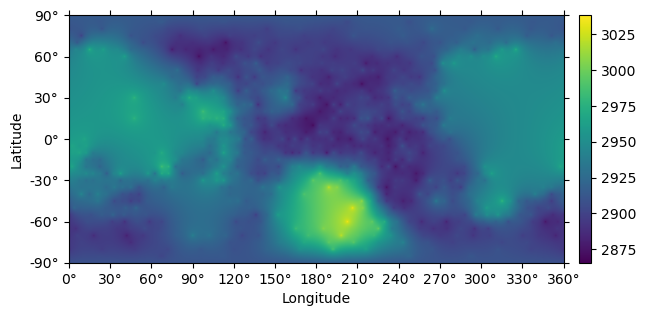

In [4]:
density_grid.plot(colorbar='right')

重力模型GRGM1200B

In [5]:
pot=pysh.datasets.Moon.GRGM1200B()
pot.set_omega(bl.Moon2015.angular_velocity)
pot=pot.change_ref(gm=bl.Moon2015.geocentric_grav_const, r0=bl.Moon2015.radius)
grgm1200 = pot
print(grgm1200)

  name = 'GRGM1200B (Moon)'
  kind = 'real'
  normalization = '4pi'
  csphase = 1
  lmax = 1200
  GM (m3 / s2) = 4902800070000.0
  r0 (m) = 1737151
  omega (rad / s) = 2.6617073e-06
  error_kind = 'unspecified'
  header = ['4.9028001224452998E+12', '1.7380000000000000E+06', '1200', '1200']
  header2 = None
  epoch = None


使用内置的地形数据

In [6]:
topo = pysh.datasets.Moon.LDEM_shape_pa(lmax=1200)
topo.r0 = topo.coeffs[0, 0, 0]

设置参数

In [7]:
thickave = 35.e3
porosity = 0.12
rho_c = 2550.0
rho_m = 3220.0
filter = 1
half = 80

执行反演程序

In [8]:
moho = pyMohoRho(grgm1200, topo, density, porosity, 1200, rho_m, thickave,
                filter_type=filter, half=half, lmax_calc=719,
                quiet=False, delta_max=50.)

Maximum radius (km) = 1748.121126
Minimum radius (km) = 1728.204994
Maximum density (kg/m3) = 3.038178
Minimum desntiy (kg/m3) = 2.865771
Maximum Crustal thickness (km) = 66.564270
Minimum Crustal thickness (km) = -13.639915
Delta (km) = 4.565473e+01
Maximum Crustal thickness (km) = 67.251318
Minimum Crustal thickness (km) = -1.034141
Iteration 1
Delta (km) = 2.282737e+01
Maximum Crustal thickness (km) = 6.664099e+01
Minimum Crustal thickness (km) = 7.791888e-01
Iteration 2
Delta (km) = 1.520594e+01
Maximum Crustal thickness (km) = 67.565480
Minimum Crustal thickness (km) = -5.704816
Iteration 3
Delta (km) = 7.602969e+00
Maximum Crustal thickness (km) = 6.702979e+01
Minimum Crustal thickness (km) = 2.258335e-01
Iteration 4
Delta (km) = 1.118248e+00
Maximum Crustal thickness (km) = 67.783420
Minimum Crustal thickness (km) = 0.585656
Iteration 5
Delta (km) = 5.591241e-01
Maximum Crustal thickness (km) = 6.740661e+01
Minimum Crustal thickness (km) = 4.057450e-01
Iteration 6
Delta (km) = 5

In [9]:
thick_grid = (topo.pad(1200) - moho.pad(1200)).expand(grid='DH2') / 1.e3

(<Figure size 640x428.8 with 2 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

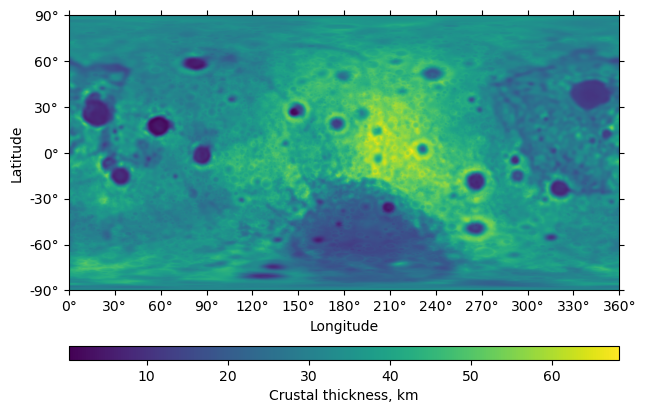

In [10]:
thick_grid.plot(show=True, colorbar='bottom',
                    cb_label='Crustal thickness, km',
                    fname='Thick-Moon-run1.png')

In [11]:
import pickle

pkl_name=result_filename
result={
    "moho": moho,
    "thick_grid": thick_grid,
    "topo": topo,
    "grgm1200": grgm1200,
}
with open(pkl_name, "wb") as f:
    pickle.dump(result, f)